# Mode-Split Modeling

The ESG score distributions are strongly bimodal — companies cluster around ~200 (low-disclosure) and ~510 (high-disclosure). A single ElasticNet trained on the full dataset must learn two fundamentally different relationships simultaneously, which suppresses R².

**This notebook implements a two-stage pipeline:**
1. **Mode classifier** — a shallow decision tree (depth=3) trained on features to predict which mode a company belongs to (environment_score ≥ 500 = high-disclosure mode). Fitted on training data only to avoid leakage.
2. **Mode-specific ElasticNet** — separate ElasticNet models trained within each mode for all four ESG targets.

**Evaluation compares three approaches:**
- Unified model (single ElasticNet on all companies — baseline from final_model_validation.ipynb)
- Oracle mode-split (use true mode labels at test time — upper bound)
- Predicted mode-split (use mode classifier predictions at test time — real deployment scenario)

**Feature set:** updated FinBERT (300-sentence cap) + SEC structured + extended structural + LSA (50 components)

## Step 1 — Imports and Paths

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import ElasticNetCV
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

BASE_DIR         = os.path.abspath('..')
FINBERT_PATH     = os.path.join(BASE_DIR, 'data', 'finbert_features', 'finbert_features.csv')
ESG_PATH         = os.path.join(BASE_DIR, 'data', 'ESG_data_cleaned.csv')
STRUCTURED_PATH  = os.path.join(BASE_DIR, 'data', 'structured_features', 'sec_fundamentals.csv')
QUALITY_PATH     = os.path.join(BASE_DIR, 'data', 'structured_features', 'extraction_quality.csv')
EXT_STRUCT_PATH  = os.path.join(BASE_DIR, 'data', 'structured_features', 'extended_structural_features.csv')
LSA_PATH         = os.path.join(BASE_DIR, 'data', 'finbert_features', 'lsa_features.csv')
OUTPUT_DIR       = os.path.join(BASE_DIR, 'data', 'finbert_features')

TARGETS      = ['total_score', 'environment_score', 'social_score', 'governance_score']
RANDOM_STATE = 42
MODE_THRESHOLD = 500  # environment_score boundary separating the two modes

print('Paths:')
for label, p in [('finbert', FINBERT_PATH), ('esg', ESG_PATH), ('structured', STRUCTURED_PATH),
                  ('quality', QUALITY_PATH), ('ext_struct', EXT_STRUCT_PATH), ('lsa', LSA_PATH)]:
    print(f'  {"OK" if os.path.exists(p) else "MISSING"}: {label}')

Paths:
  OK: finbert
  OK: esg
  OK: structured
  OK: quality
  OK: ext_struct
  OK: lsa


## Step 2 — Load and Engineer Features

In [2]:
# ── Load FinBERT features (300-sentence cap) and ESG labels ──────────────────
finbert = pd.read_csv(FINBERT_PATH)
finbert['ticker'] = finbert['ticker'].str.upper()

esg = pd.read_csv(ESG_PATH)[['ticker', 'industry', 'environment_score', 'social_score',
                               'governance_score', 'total_score', 'total_grade']]
esg['ticker'] = esg['ticker'].str.upper()

df = finbert.merge(esg, on='ticker', how='inner')
print(f'After merging FinBERT + ESG labels: {df.shape}')

# ── Step 7.5: Feature engineering ───────────────────────────────────────────
ZERO_VAR = ['num_sections', 'kw_employee_welfare_present', 'has_women_leadership',
            'count_women_leadership', 'has_board_independence', 'count_board_independence']
NEAR_UNIVERSAL = ['kw_ethics_compliance_present', 'kw_transparency_present',
                  'kw_regulatory_penalties_present', 'kw_diversity_present',
                  'kw_board_governance_present']
DROP_COLS = ZERO_VAR + NEAR_UNIVERSAL

eng = df.copy()
for pillar in ['E', 'S', 'G']:
    col = f'{pillar}_pos_neg_ratio'
    eng[col] = eng[col].clip(upper=eng[col].quantile(0.99))

kw_freq_cols = [c for c in eng.columns if c.startswith('kw_') and c.endswith('_freq')]
for col in kw_freq_cols:
    eng[f'{col}_log'] = np.log1p(eng[col])
DROP_COLS += kw_freq_cols

eng.drop(columns=[c for c in DROP_COLS if c in eng.columns], inplace=True)
ind_dummies = pd.get_dummies(eng['industry'], prefix='ind')
eng = pd.concat([eng, ind_dummies], axis=1)
print(f'After Step 7.5 feature engineering: {eng.shape}')

After merging FinBERT + ESG labels: (332, 83)
After Step 7.5 feature engineering: (332, 110)


In [3]:
# ── Step 7.6: SEC structured features ───────────────────────────────────────
STRUCTURED_COLS = ['log_total_assets', 'log_public_float', 'debt_to_assets',
                   'profit_margin', 'return_on_equity']
sec_df = pd.read_csv(STRUCTURED_PATH)
sec_df['ticker'] = sec_df['ticker'].str.upper()
available = [c for c in STRUCTURED_COLS if c in sec_df.columns]
sec_merge = sec_df[['ticker'] + available].merge(
    eng[['ticker', 'industry']].drop_duplicates(), on='ticker', how='left'
)
for col in available:
    ind_med = sec_merge.groupby('industry')[col].transform('median')
    sec_merge[col] = sec_merge[col].fillna(ind_med).fillna(sec_merge[col].median())
for col in ['debt_to_assets', 'profit_margin', 'return_on_equity']:
    if col in available:
        lo, hi = sec_merge[col].quantile([0.01, 0.99])
        sec_merge[col] = sec_merge[col].clip(lo, hi)
sec_merge.drop(columns=['industry'], inplace=True)
eng = eng.merge(sec_merge, on='ticker', how='left')
for col in available:
    eng[col] = eng[col].fillna(eng[col].median())
print(f'After SEC structured merge: {eng.shape}')

# ── Step 7.7: Filter bad extractions ────────────────────────────────────────
eq_df = pd.read_csv(QUALITY_PATH)
eq_df['ticker'] = eq_df['ticker'].str.upper()
eng = eng.merge(eq_df[['ticker', 'bad_extraction']], on='ticker', how='left')
eng['bad_extraction'] = eng['bad_extraction'].fillna(0).astype(int)
pre = len(eng)
eng = eng[eng['bad_extraction'] < 2].drop(columns=['bad_extraction'])
print(f'After quality filter: {pre} -> {len(eng)} companies')

# ── Merge extended structural features ──────────────────────────────────────
ext = pd.read_csv(EXT_STRUCT_PATH)
ext['ticker'] = ext['ticker'].str.upper()
eng = eng.merge(ext, on='ticker', how='left')
print(f'After extended structural merge: {eng.shape}')

# ── Merge LSA features ───────────────────────────────────────────────────────
lsa = pd.read_csv(LSA_PATH)
lsa['ticker'] = lsa['ticker'].str.upper()
eng = eng.merge(lsa, on='ticker', how='left')
print(f'After LSA merge: {eng.shape}')

# Final NaN fill for any merge gaps
EXCLUDE = ['ticker', 'industry', 'environment_score', 'social_score',
           'governance_score', 'total_score', 'total_grade']
feature_cols = [c for c in eng.columns if c not in EXCLUDE]
eng[feature_cols] = eng[feature_cols].fillna(0)
print(f'\nFinal feature matrix: {len(eng)} companies x {len(feature_cols)} features')

After SEC structured merge: (332, 115)
After quality filter: 332 -> 323 companies
After extended structural merge: (323, 136)
After LSA merge: (323, 186)

Final feature matrix: 323 companies x 179 features


## Step 3 — Train/Test Split and Mode Labels

In [4]:
X = eng[feature_cols].values
y_mode = (eng['environment_score'] >= MODE_THRESHOLD).astype(int).values

# Single split — same seed as final_model_validation for consistency
(X_train, X_test,
 y_mode_train, y_mode_test,
 idx_train, idx_test) = train_test_split(
    X, y_mode, eng.index,
    test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Mode distribution — Train: {y_mode_train.sum()} high / {(y_mode_train==0).sum()} low '
      f'({y_mode_train.mean():.1%} high)')
print(f'Mode distribution — Test:  {y_mode_test.sum()} high / {(y_mode_test==0).sum()} low '
      f'({y_mode_test.mean():.1%} high)')

Train: 258, Test: 65
Mode distribution — Train: 132 high / 126 low (51.2% high)
Mode distribution — Test:  39 high / 26 low (60.0% high)


## Step 4 — Mode Classifier (Decision Tree, Depth=3)

In [5]:
# Fit on training data only — avoids leakage when assigning test modes
mode_clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15,
                                   class_weight='balanced', random_state=RANDOM_STATE)
mode_clf.fit(X_train, y_mode_train)

cv_acc = cross_val_score(mode_clf, X_train, y_mode_train, cv=5, scoring='accuracy')
test_acc = mode_clf.score(X_test, y_mode_test)
print(f'Mode classifier — 5-fold CV accuracy: {cv_acc.mean():.3f} ± {cv_acc.std():.3f}')
print(f'Mode classifier — Test accuracy:       {test_acc:.3f}')
print()
print(classification_report(y_mode_test, mode_clf.predict(X_test),
                             target_names=['low-disclosure', 'high-disclosure']))

print('\nDecision rules:')
print(export_text(mode_clf, feature_names=feature_cols, max_depth=3))

Mode classifier — 5-fold CV accuracy: 0.616 ± 0.050
Mode classifier — Test accuracy:       0.615

                 precision    recall  f1-score   support

 low-disclosure       0.52      0.54      0.53        26
high-disclosure       0.68      0.67      0.68        39

       accuracy                           0.62        65
      macro avg       0.60      0.60      0.60        65
   weighted avg       0.62      0.62      0.62        65


Decision rules:
|--- log_public_float <= 23.30
|   |--- E_coverage_pct <= 0.03
|   |   |--- lsa_00 <= 0.87
|   |   |   |--- class: 0
|   |   |--- lsa_00 >  0.87
|   |   |   |--- class: 0
|   |--- E_coverage_pct >  0.03
|   |   |--- class: 1
|--- log_public_float >  23.30
|   |--- lsa_41 <= 0.04
|   |   |--- lsa_08 <= -0.01
|   |   |   |--- class: 1
|   |   |--- lsa_08 >  -0.01
|   |   |   |--- class: 1
|   |--- lsa_41 >  0.04
|   |   |--- class: 0



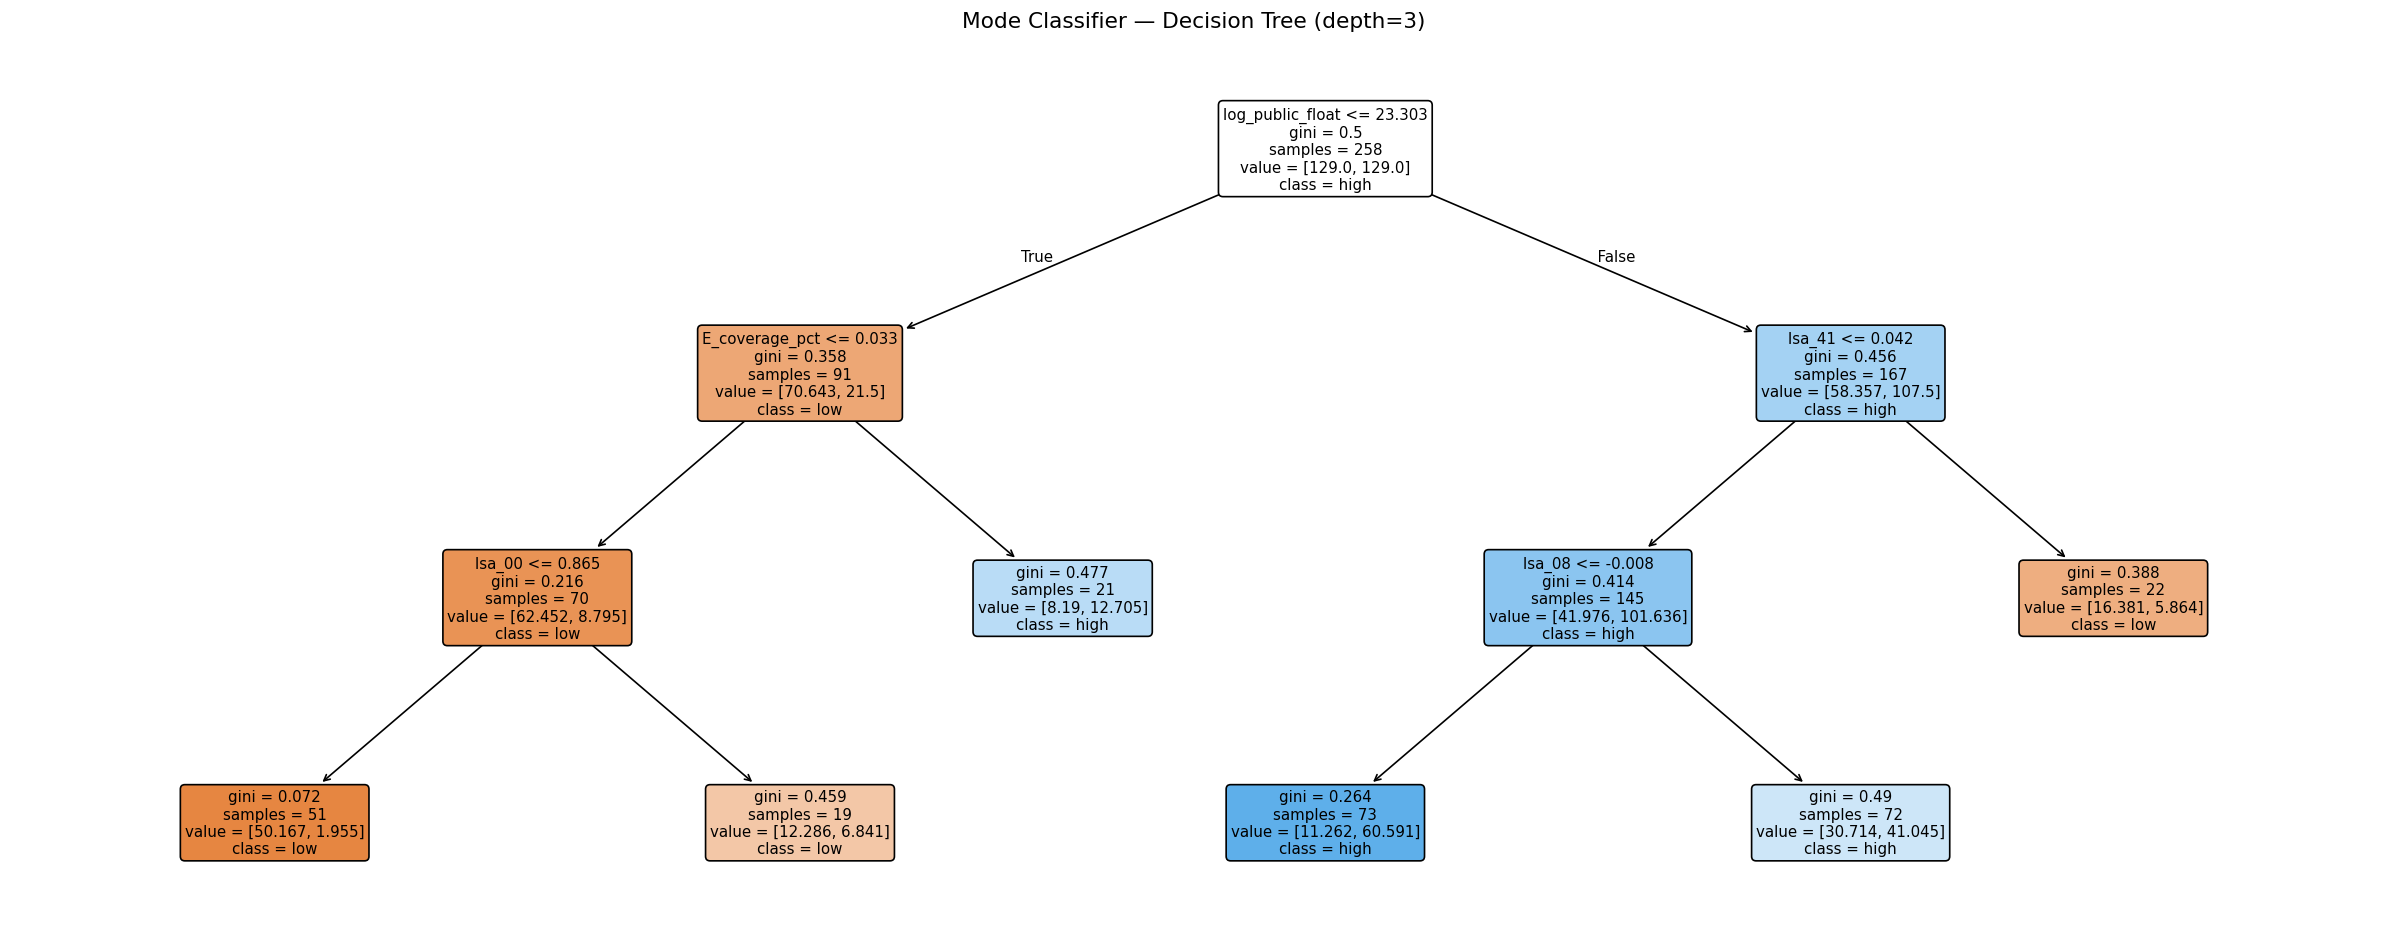

Tree plot saved.


In [6]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(mode_clf, feature_names=feature_cols,
          class_names=['low', 'high'], filled=True, rounded=True,
          fontsize=9, ax=ax)
plt.title('Mode Classifier — Decision Tree (depth=3)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mode_classifier_tree.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Tree plot saved.')

## Step 5 — Unified ElasticNet Baseline (Full Dataset)

In [7]:
scaler_unified = StandardScaler()
X_train_s = scaler_unified.fit_transform(X_train)
X_test_s  = scaler_unified.transform(X_test)

l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99]
unified_results = {}

for target in TARGETS:
    y_train = eng.loc[idx_train, target].values
    y_test  = eng.loc[idx_test,  target].values

    model = ElasticNetCV(l1_ratio=l1_ratios, cv=5, random_state=RANDOM_STATE,
                         max_iter=10000, n_alphas=100)
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)

    ss_res = np.sum((y_test - y_pred) ** 2)
    ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
    r2 = 1 - ss_res / ss_tot

    unified_results[target] = {
        'r2': r2, 'mae': mean_absolute_error(y_test, y_pred),
        'n_nonzero': np.sum(model.coef_ != 0),
        'y_test': y_test, 'y_pred': y_pred
    }
    print(f'{target:25s}  R²={r2:+.4f}  MAE={mean_absolute_error(y_test,y_pred):.2f}  '
          f'nonzero={np.sum(model.coef_!=0)}/{len(feature_cols)}')

total_score                R²=+0.0307  MAE=148.34  nonzero=39/179
environment_score          R²=+0.0690  MAE=101.74  nonzero=80/179
social_score               R²=+0.1190  MAE=32.13  nonzero=73/179
governance_score           R²=+0.0105  MAE=35.80  nonzero=145/179


## Step 6 — Mode-Split ElasticNet

In [8]:
# Predict test modes using the classifier (real deployment scenario)
y_mode_pred = mode_clf.predict(X_test)

mode_results   = {}   # predicted mode
oracle_results = {}   # true mode (upper bound)

for target in TARGETS:
    y_train_all = eng.loc[idx_train, target].values
    y_test_all  = eng.loc[idx_test,  target].values

    preds_predicted = np.zeros(len(y_test_all))
    preds_oracle    = np.zeros(len(y_test_all))

    for mode in [0, 1]:
        # ── Training: split by true mode labels ──────────────────────────────
        train_mask = y_mode_train == mode
        if train_mask.sum() < 10:
            print(f'  [{target}] mode={mode} has only {train_mask.sum()} train samples — skipping')
            continue

        X_tr_m = X_train[train_mask]
        y_tr_m = y_train_all[train_mask]

        scaler_m = StandardScaler()
        X_tr_m_s = scaler_m.fit_transform(X_tr_m)

        model_m = ElasticNetCV(l1_ratio=l1_ratios, cv=5, random_state=RANDOM_STATE,
                               max_iter=10000, n_alphas=100)
        model_m.fit(X_tr_m_s, y_tr_m)

        # ── Test: predicted mode ─────────────────────────────────────────────
        pred_mask = y_mode_pred == mode
        if pred_mask.sum() > 0:
            X_te_pred_s = scaler_m.transform(X_test[pred_mask])
            preds_predicted[pred_mask] = model_m.predict(X_te_pred_s)

        # ── Test: oracle mode ────────────────────────────────────────────────
        oracle_mask = y_mode_test == mode
        if oracle_mask.sum() > 0:
            X_te_oracle_s = scaler_m.transform(X_test[oracle_mask])
            preds_oracle[oracle_mask] = model_m.predict(X_te_oracle_s)

    def r2(y, yp):
        ss_res = np.sum((y - yp) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - ss_res / ss_tot

    mode_results[target]   = {'r2': r2(y_test_all, preds_predicted),
                               'mae': mean_absolute_error(y_test_all, preds_predicted)}
    oracle_results[target] = {'r2': r2(y_test_all, preds_oracle),
                               'mae': mean_absolute_error(y_test_all, preds_oracle)}

    print(f'{target:25s}  '
          f'unified={unified_results[target]["r2"]:+.4f}  '
          f'mode-split={mode_results[target]["r2"]:+.4f}  '
          f'oracle={oracle_results[target]["r2"]:+.4f}')

total_score                unified=+0.0307  mode-split=-0.4591  oracle=+0.5995
environment_score          unified=+0.0690  mode-split=-0.4632  oracle=+0.7438
social_score               unified=+0.1190  mode-split=-0.0929  oracle=+0.2435
governance_score           unified=+0.0105  mode-split=-0.2494  oracle=+0.0460


## Step 7 — Comparison Table and Visualization

In [9]:
rows = []
for target in TARGETS:
    rows.append({
        'Target':           target.replace('_score', '').replace('_', ' ').title(),
        'Unified R²':       round(unified_results[target]['r2'], 4),
        'Mode-Split R²':    round(mode_results[target]['r2'], 4),
        'Oracle R²':        round(oracle_results[target]['r2'], 4),
        'ΔR² (split-uni)':  round(mode_results[target]['r2'] - unified_results[target]['r2'], 4),
        'ΔR² (oracle-uni)': round(oracle_results[target]['r2'] - unified_results[target]['r2'], 4),
    })

comparison = pd.DataFrame(rows).set_index('Target')
print(comparison.to_string())
comparison.to_csv(os.path.join(OUTPUT_DIR, 'mode_split_comparison.csv'))
print('\nSaved mode_split_comparison.csv')

             Unified R²  Mode-Split R²  Oracle R²  ΔR² (split-uni)  ΔR² (oracle-uni)
Target                                                                              
Total            0.0307        -0.4591     0.5995          -0.4898            0.5688
Environment      0.0690        -0.4632     0.7438          -0.5322            0.6748
Social           0.1190        -0.0929     0.2435          -0.2119            0.1246
Governance       0.0105        -0.2494     0.0460          -0.2599            0.0355

Saved mode_split_comparison.csv


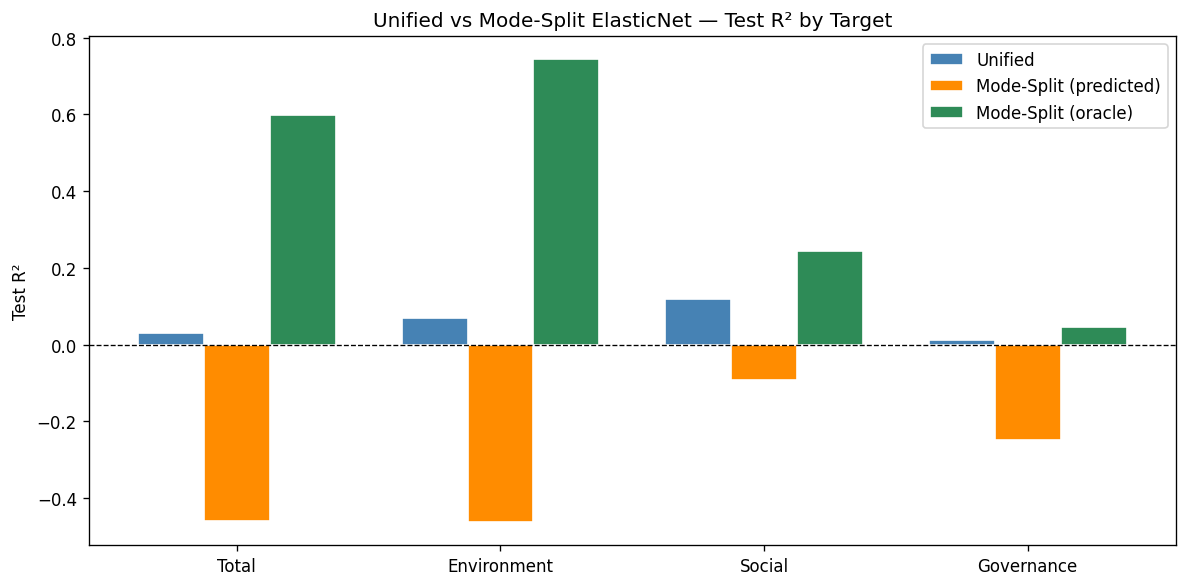

Comparison plot saved.


In [10]:
targets_short = [t.replace('_score', '').title() for t in TARGETS]
x = np.arange(len(TARGETS))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, [unified_results[t]['r2'] for t in TARGETS], width,
       label='Unified', color='steelblue', edgecolor='white')
ax.bar(x,          [mode_results[t]['r2']   for t in TARGETS], width,
       label='Mode-Split (predicted)', color='darkorange', edgecolor='white')
ax.bar(x + width,  [oracle_results[t]['r2'] for t in TARGETS], width,
       label='Mode-Split (oracle)', color='seagreen', edgecolor='white')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(targets_short)
ax.set_ylabel('Test R²')
ax.set_title('Unified vs Mode-Split ElasticNet — Test R² by Target')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'mode_split_r2_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Comparison plot saved.')

## Step 8 — Summary

In [11]:
print('=' * 65)
print('MODE-SPLIT MODELING SUMMARY')
print('=' * 65)
print(f'Mode threshold:   environment_score >= {MODE_THRESHOLD}')
print(f'Mode classifier:  Decision Tree depth=3, '
      f'test accuracy={mode_clf.score(X_test, y_mode_test):.3f}')
print()
print('Interpretation:')
for target in TARGETS:
    delta = mode_results[target]['r2'] - unified_results[target]['r2']
    direction = 'improved' if delta > 0 else 'degraded'
    print(f'  {target:25s}: mode-split {direction} R² by {delta:+.4f} '
          f'(oracle ceiling: {oracle_results[target]["r2"]:+.4f})')

MODE-SPLIT MODELING SUMMARY
Mode threshold:   environment_score >= 500
Mode classifier:  Decision Tree depth=3, test accuracy=0.615

Interpretation:
  total_score              : mode-split degraded R² by -0.4898 (oracle ceiling: +0.5995)
  environment_score        : mode-split degraded R² by -0.5322 (oracle ceiling: +0.7438)
  social_score             : mode-split degraded R² by -0.2119 (oracle ceiling: +0.2435)
  governance_score         : mode-split degraded R² by -0.2599 (oracle ceiling: +0.0460)
